In [5]:
!uv add alpaca-py matplotlib pandas

Resolved 143 packages in 259ms                                       
⠙ Preparing packages... (0/5)                                                   
⠙ Preparing packages... (0/5)-------------------     0 B/267.56 KiB          
⠙ Preparing packages... (0/5)-------------------     0 B/267.56 KiB          
contourpy            ------------------------------     0 B/267.56 KiB
⠙ Preparing packages... (0/5)-------------------     0 B/2.74 MiB            
contourpy            ------------------------------     0 B/267.56 KiB
⠙ Preparing packages... (0/5)-------------------     0 B/2.74 MiB            
contourpy            ------------------------------     0 B/267.56 KiB
⠙ Preparing packages... (0/5)-------------------     0 B/2.74 MiB            
kiwisolver           ------------------------------     0 B/62.57 KiB
contourpy            ------------------------------     0 B/267.56 KiB
⠙ Preparing packages... (0/5)-------------------     0 B/2.74 MiB            
kiwisolver           ------

# Alpaca API - Complete Trading Examples

A comprehensive guide to using the Alpaca Trading API for paper trading, market data retrieval, and portfolio management with practical examples.

## 1. Install and Import Dependencies

Install and verify the required packages for Alpaca trading and data analysis.

In [1]:
# Install required packages (via uv or pip)
# !uv add alpaca python-dotenv pandas numpy matplotlib
# or: !pip install alpaca-py python-dotenv pandas numpy matplotlib

import os
from dotenv import load_dotenv
from alpaca.trading.client import TradingClient
from alpaca.data.historical.stock import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest, StockLatestBarRequest
from alpaca.data.timeframe import TimeFrame
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Verify alpaca-py is installed
import alpaca
print(f"Alpaca SDK version: {alpaca.__version__}")
print("All dependencies imported successfully!")

Alpaca SDK version: 0.43.2
All dependencies imported successfully!


## 2. Configure API Credentials with Environment Variables

Load your Alpaca API credentials from environment variables or a .env file for secure configuration.

In [ ]:
# Load environment variables from .env file
load_dotenv()

# Get API credentials
# API_KEY = os.getenv("ALPACA_API_KEY")
API_KEY = os.getenv('API_KEY')
SECRET_KEY = os.getenv('SECRET_KEY')
BASE_URL = "https://paper-api.alpaca.markets"  # Paper trading endpoint

# Verify credentials are loaded
if not API_KEY or not SECRET_KEY:
    print("⚠️  WARNING: API credentials not found!")
    print("Please set API_KEY and SECRET_KEY in your .env file")
else:
    print("✓ API credentials loaded successfully")
    print(f"Base URL: {BASE_URL} (Paper Trading)")

✓ API credentials loaded successfully
Base URL: https://paper-api.alpaca.markets (Paper Trading)


## 3. Initialize Alpaca Trading and Market Data Clients

Create trading and data client instances configured for paper trading with connectivity verification.

In [3]:
# Initialize Trading Client (Paper Trading)
trading_client = TradingClient(
    api_key=API_KEY,
    secret_key=SECRET_KEY,
    paper=True  # Use paper trading
)

# Initialize Market Data Client
data_client = StockHistoricalDataClient(
    api_key=API_KEY,
    secret_key=SECRET_KEY
)

# Test connectivity
try:
    account = trading_client.get_account()
    print("✓ Trading Client connected successfully")
    print(f"  Account Status: {account.status}")
except Exception as e:
    print(f"✗ Failed to connect: {e}")

✓ Trading Client connected successfully
  Account Status: AccountStatus.ACTIVE


## 4. Fetch Account Details and Buying Power

Retrieve and display key account information including equity, cash, and available buying power.

In [4]:
# Get account details
account = trading_client.get_account()

# Display key account information
account_info = {
    "Account Status": account.status,
    "Equity": f"${float(account.equity):.2f}",
    "Cash": f"${float(account.cash):.2f}",
    "Buying Power": f"${float(account.buying_power):.2f}",
    "Portfolio Value": f"${float(account.portfolio_value):.2f}",
    "Pattern Day Trading": account.pattern_day_trader,
}

account_df = pd.DataFrame(list(account_info.items()), columns=["Field", "Value"])
print("Account Details:")
print(account_df.to_string(index=False))

Account Details:
              Field                Value
     Account Status AccountStatus.ACTIVE
             Equity           $100084.15
               Cash            $99543.69
       Buying Power           $199627.84
    Portfolio Value           $100084.15
Pattern Day Trading                False


## 5. List Tradable Assets and Filter by Exchange

Retrieve available assets and filter by exchange or other criteria.

In [10]:
# Get all tradable assets
all_assets = trading_client.get_all_assets()

# Filter for NASDAQ stocks
nasdaq_assets = [asset for asset in all_assets if asset.exchange == "NASDAQ" and asset.tradable]

# Create DataFrame
assets_df = pd.DataFrame([
    {
        "Symbol": asset.symbol,
        "Name": asset.name,
        "Exchange": asset.exchange,
        "Tradable": asset.tradable,
        "Shortable": asset.shortable
    }
    for asset in nasdaq_assets[:10]  # Show first 10
])

print(f"Total tradable assets: {len([a for a in all_assets if a.tradable])}")
print(f"\nNASDAQ Assets (first 10):")
print(assets_df.to_string(index=False))

Total tradable assets: 12822

NASDAQ Assets (first 10):
Symbol                                                         Name             Exchange  Tradable  Shortable
   RRR                  Red Rock Resorts, Inc. Class A Common Stock AssetExchange.NASDAQ      True       True
  IOYY    GraniteShares ETF Trust GraniteShares YieldBOOST IONQ ETF AssetExchange.NASDAQ      True      False
  IONZ       Tidal Trust II Defiance Daily Target 2x Short IONQ ETF AssetExchange.NASDAQ      True      False
  IONX        Tidal Trust II Defiance Daily Target 2X Long IONQ ETF AssetExchange.NASDAQ      True      False
  IONR                        ioneer Ltd American Depositary Shares AssetExchange.NASDAQ      True      False
  IONL GraniteShares ETF Trust GraniteShares 2x Long IONQ Daily ETF AssetExchange.NASDAQ      True      False
  RSVR                           Reservoir Media, Inc. Common Stock AssetExchange.NASDAQ      True       True
  INVZ                    Innoviz Technologies Ltd. Ordinary sha

## 6. Request Historical Bars for a Symbol

Retrieve historical OHLCV data for a stock and visualize the price movement.

Retrieved 20 bars for AAPL

Last 5 bars:
                timestamp    open   high    low  close     volume
2026-04-13 04:00:00+00:00 259.730 260.18 256.66 259.20 36408224.0
2026-04-14 04:00:00+00:00 259.245 261.93 257.19 258.83 48524835.0
2026-04-15 04:00:00+00:00 258.160 266.56 257.81 266.43 50072607.0
2026-04-16 04:00:00+00:00 266.800 267.16 261.27 263.40 43478258.0
2026-04-17 04:00:00+00:00 266.960 272.30 266.72 270.23 61597694.0


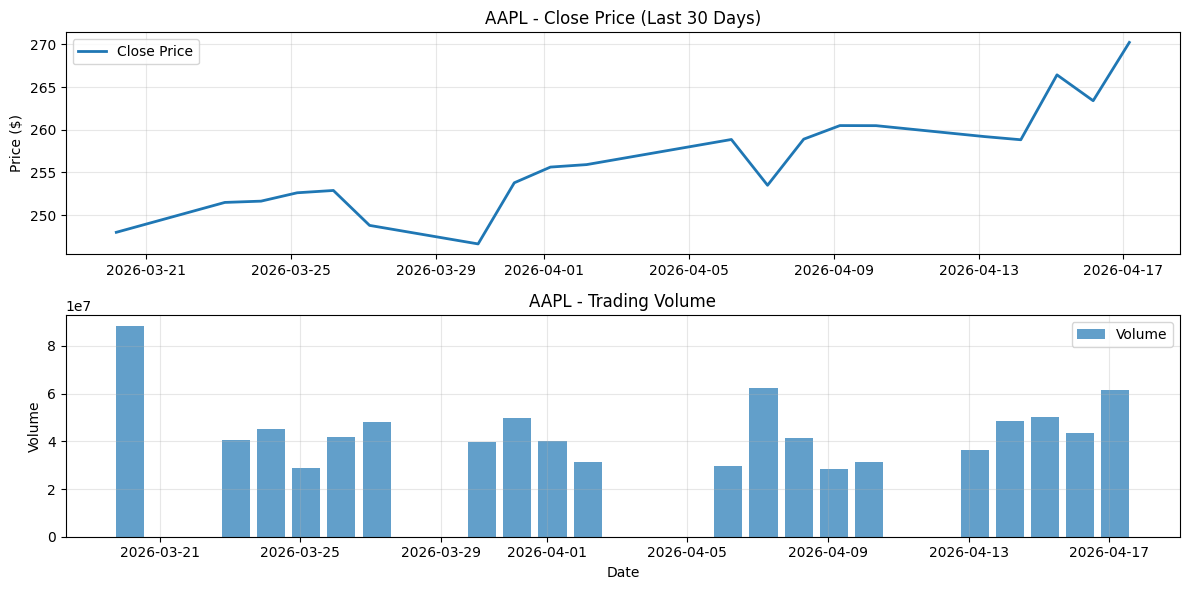

In [11]:
# Request historical bars for AAPL
start_date = datetime.now() - timedelta(days=30)

bars_request = StockBarsRequest(
    symbol_or_symbols="AAPL",
    timeframe=TimeFrame.Day,
    start=start_date
)

# Get historical data
bars = data_client.get_stock_bars(bars_request)
bars_df = bars.df

# Reset index to make date a column
bars_df = bars_df.reset_index()

print(f"Retrieved {len(bars_df)} bars for AAPL")
print("\nLast 5 bars:")
print(bars_df[['timestamp', 'open', 'high', 'low', 'close', 'volume']].tail().to_string(index=False))

# Plot close price and volume
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(bars_df['timestamp'], bars_df['close'], label='Close Price', linewidth=2)
ax1.set_ylabel('Price ($)')
ax1.set_title('AAPL - Close Price (Last 30 Days)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(bars_df['timestamp'], bars_df['volume'], label='Volume', alpha=0.7)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.set_title('AAPL - Trading Volume')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Compute Basic Indicators from Retrieved Data

Calculate moving averages and daily returns from historical bar data.

Indicator Calculation Summary:
Current Price: $270.23
SMA 20: $256.39
SMA 50: $nan
Average Daily Return: 0.46%


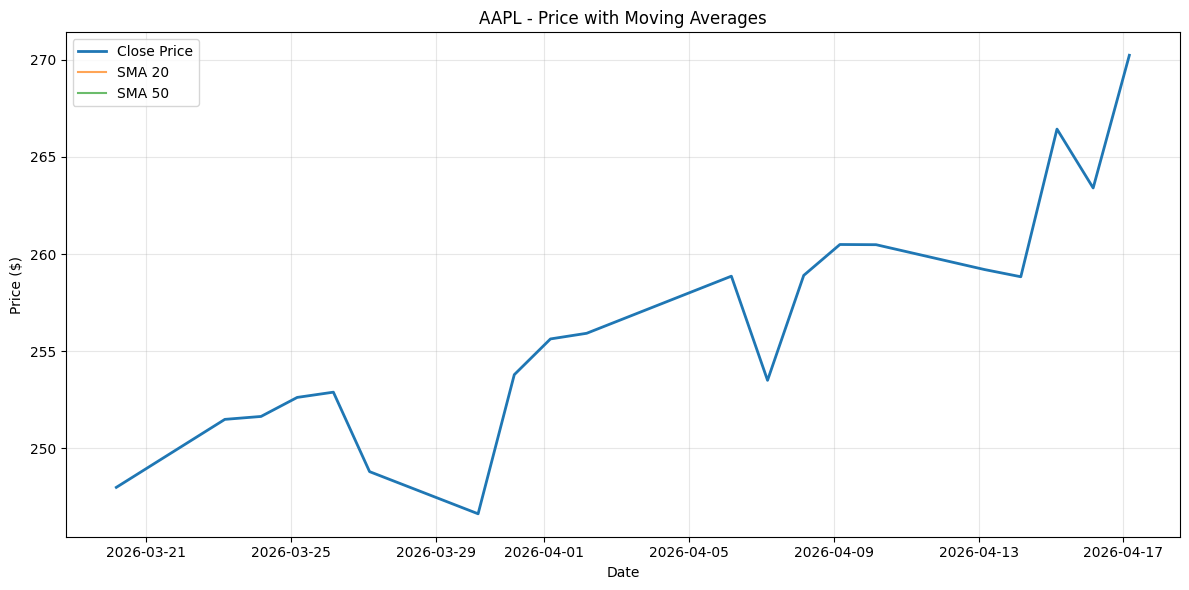

In [12]:
# Calculate indicators on the bars data
bars_df = bars_df.sort_values('timestamp')

# Simple Moving Averages
bars_df['SMA_20'] = bars_df['close'].rolling(window=20).mean()
bars_df['SMA_50'] = bars_df['close'].rolling(window=50).mean()

# Daily returns
bars_df['Daily_Return'] = bars_df['close'].pct_change() * 100

print("Indicator Calculation Summary:")
print(f"Current Price: ${bars_df['close'].iloc[-1]:.2f}")
print(f"SMA 20: ${bars_df['SMA_20'].iloc[-1]:.2f}")
print(f"SMA 50: ${bars_df['SMA_50'].iloc[-1]:.2f}")
print(f"Average Daily Return: {bars_df['Daily_Return'].mean():.2f}%")

# Plot indicators
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(bars_df['timestamp'], bars_df['close'], label='Close Price', linewidth=2)
ax.plot(bars_df['timestamp'], bars_df['SMA_20'], label='SMA 20', linewidth=1.5, alpha=0.7)
ax.plot(bars_df['timestamp'], bars_df['SMA_50'], label='SMA 50', linewidth=1.5, alpha=0.7)

ax.set_ylabel('Price ($)')
ax.set_xlabel('Date')
ax.set_title('AAPL - Price with Moving Averages')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Submit a Paper Market Order

Create and submit a market buy order in paper trading mode.

In [13]:
# Import order classes
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce

# Create a market buy order
market_order_data = MarketOrderRequest(
    symbol="AAPL",
    qty=1,
    side=OrderSide.BUY,
    time_in_force=TimeInForce.DAY
)

# Submit the order
try:
    market_order = trading_client.submit_order(market_order_data)
    
    print("✓ Order submitted successfully!")
    print(f"  Order ID: {market_order.id}")
    print(f"  Symbol: {market_order.symbol}")
    print(f"  Quantity: {market_order.qty}")
    print(f"  Side: {market_order.side}")
    print(f"  Status: {market_order.status}")
    print(f"  Order Type: {market_order.order_type}")
except Exception as e:
    print(f"✗ Failed to submit order: {e}")

✓ Order submitted successfully!
  Order ID: 94268e31-36b5-4f63-9b92-d7ee975bba3b
  Symbol: AAPL
  Quantity: 1
  Side: OrderSide.BUY
  Status: OrderStatus.ACCEPTED
  Order Type: OrderType.MARKET


## 9. Check Open Positions and Open Orders

Query and display all open positions and pending orders with their details.

In [15]:
# Get all positions
positions = trading_client.get_all_positions()

if positions:
    positions_df = pd.DataFrame([
        {
            "Symbol": pos.symbol,
            "Qty": pos.qty,
            "Avg Entry Price": f"${float(pos.avg_entry_price):.2f}",
            "Current Price": f"${float(pos.current_price):.2f}",
            "Unrealized P&L": f"${float(pos.unrealized_pl):.2f}",
            "Return %": f"{float(pos.unrealized_plpc)*100:.2f}%"
        }
        for pos in positions
    ])
    print("Open Positions:")
    print(positions_df.to_string(index=False))
else:
    print("No open positions")

print("\n" + "="*50 + "\n")

# Get all orders
orders = trading_client.get_orders()

if orders:
    orders_df = pd.DataFrame([
        {
            "Order ID": str(order.id)[:8],
            "Symbol": order.symbol,
            "Side": order.side,
            "Qty": order.qty,
            "Status": order.status,
            "Filled Qty": order.filled_qty,
            "Filled Price": f"${float(order.filled_avg_price):.2f}" if order.filled_avg_price else "N/A"
        }
        for order in orders[:5]  # Show first 5
    ])
    print(f"Open Orders ({len(orders)} total):")
    print(orders_df.to_string(index=False))
else:
    print("No open orders")

Open Positions:
Symbol Qty Avg Entry Price Current Price Unrealized P&L Return %
  AAPL   2         $228.15       $270.23         $84.16   18.44%


Open Orders (1 total):
Order ID Symbol          Side Qty               Status Filled Qty Filled Price
94268e31   AAPL OrderSide.BUY   1 OrderStatus.ACCEPTED          0          N/A


## 10. Cancel Orders and Close a Position

Demonstrate how to cancel open orders and close existing positions with safety checks.

In [17]:
# Example: Cancel an order
orders = trading_client.get_orders()

if orders:
    order_to_cancel = orders[0]
    try:
        trading_client.cancel_order_by_id(order_to_cancel.id)
        print(f"✓ Order {str(order_to_cancel.id)[:8]} cancelled successfully")
    except Exception as e:
        print(f"✗ Failed to cancel order: {e}")
else:
    print("No open orders to cancel")

print("\n" + "="*50 + "\n")

# Example: Close a position
positions = trading_client.get_all_positions()

if positions:
    position_to_close = positions[0]
    close_order = MarketOrderRequest(
        symbol=position_to_close.symbol,
        qty=abs(float(position_to_close.qty)),
        side=OrderSide.SELL if float(position_to_close.qty) > 0 else OrderSide.BUY,
        time_in_force=TimeInForce.DAY
    )
    
    try:
        close_order_response = trading_client.submit_order(close_order)
        print(f"✓ Position closed: {position_to_close.symbol}")
        print(f"  Closed {position_to_close.qty} shares at market")
        print(f"  Order ID: {str(close_order_response.id)[:8]}")
    except Exception as e:
        print(f"✗ Failed to close position: {e}")
else:
    print("No open positions to close")

No open orders to cancel


✓ Position closed: AAPL
  Closed 2 shares at market
  Order ID: a3acc68f


## 11. Stream Real-Time Trades with WebSocket

Set up a simple WebSocket connection to stream trade and quote updates for selected symbols.

In [ ]:
# WebSocket streaming example
from alpaca.data.live import StockDataStream

# Initialize data stream client
wss_client = StockDataStream(API_KEY, SECRET_KEY)

# Define handler functions
async def quote_data_handler(data):
    print(f"Quote: {data.symbol} - Bid: ${data.bid_price:.2f}, Ask: ${data.ask_price:.2f}")

async def trade_data_handler(data):
    print(f"Trade: {data.symbol} - Price: ${data.price:.2f}, Size: {data.size}")

# Subscribe to quotes and trades
# wss_client.subscribe_quotes(quote_data_handler, "AAPL", "GOOGL", "MSFT")
# wss_client.subscribe_trades(trade_data_handler, "AAPL", "GOOGL", "MSFT")

print("WebSocket Streaming Setup")
print("-" * 50)
print("To enable real-time streaming, uncomment the subscribe lines above:")
print("  - quote_data_handler: Receives bid/ask price updates")
print("  - trade_data_handler: Receives executed trade information")
print("\nExample subscriptions:")
print('  wss_client.subscribe_quotes(quote_data_handler, "AAPL")')
print('  wss_client.subscribe_trades(trade_data_handler, "AAPL")')
print("\nNote: Run wss_client.run() to start receiving data")

await wss_client.run()

WebSocket Streaming Setup
--------------------------------------------------
To enable real-time streaming, uncomment the subscribe lines above:
  - quote_data_handler: Receives bid/ask price updates
  - trade_data_handler: Receives executed trade information

Example subscriptions:
  wss_client.subscribe_quotes(quote_data_handler, "AAPL")
  wss_client.subscribe_trades(trade_data_handler, "AAPL")

Note: Run wss_client.run() to start receiving data


In [3]:
# Crypto WebSocket streaming for BTC
from alpaca.data.live import CryptoDataStream

# Initialize crypto data stream client
crypto_stream = CryptoDataStream(API_KEY, SECRET_KEY)

# Define handler functions for crypto
async def crypto_quote_handler(data):
    print(f"BTC Quote - Bid: ${data.bid_price:.2f}, Ask: ${data.ask_price:.2f}")

async def crypto_trade_handler(data):
    print(f"BTC Trade - Price: ${data.price:.2f}, Size: {data.size}")

# Subscribe to BTC trades and quotes
# crypto_stream.subscribe_quotes(crypto_quote_handler, "BTC/USD")
# crypto_stream.subscribe_trades(crypto_trade_handler, "BTC/USD")

print("Crypto WebSocket Setup (BTC)")
print("-" * 50)
print("Symbols: BTC/USD, ETH/USD, etc.")
print("Available 24/7 (unlike stocks)")
print("\nExample subscriptions:")
print('  crypto_stream.subscribe_quotes(crypto_quote_handler, "BTC/USD")')
print('  crypto_stream.subscribe_trades(crypto_trade_handler, "BTC/USD")')
print("\nNote: Run crypto_stream.run() to start receiving data")

Crypto WebSocket Setup (BTC)
--------------------------------------------------
Symbols: BTC/USD, ETH/USD, etc.
Available 24/7 (unlike stocks)

Example subscriptions:
  crypto_stream.subscribe_quotes(crypto_quote_handler, "BTC/USD")
  crypto_stream.subscribe_trades(crypto_trade_handler, "BTC/USD")

Note: Run crypto_stream.run() to start receiving data


In [4]:
import asyncio

await asyncio.run(crypto_stream.run())

AttributeError: 'NoneType' object has no attribute 'is_running'